**Sub questions:**
- Determine the physical sizes of the earrings given the camera parameters

**Image:** `earrings.jpg`

**Given:**
- Focal length: `f = 8 mm`
- Pixel size: `p = 2.2 um = 0.0022 mm`
- Distance from lens to imaging plane: `720 mm`


In [1]:
import sys
print("Python:", sys.executable)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
print("cv2   :", cv.__version__)
print("numpy :", np.__version__)

# Load the earring image
img = cv.imread('../images/earrings.jpg')
assert img is not None, "Could not load earrings.jpg — check the path"

img_rgb  = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

print(f"Image shape  : {img.shape}")
print(f"Dtype        : {img.dtype}")
print(f"Width        : {img.shape[1]} px")
print(f"Height       : {img.shape[0]} px")


Python: C:\Users\user\AppData\Local\Programs\Python\Python313\python.exe
cv2   : 4.13.0
numpy : 2.4.4
Image shape  : (1024, 1024, 3)
Dtype        : uint8
Width        : 1024 px
Height       : 1024 px


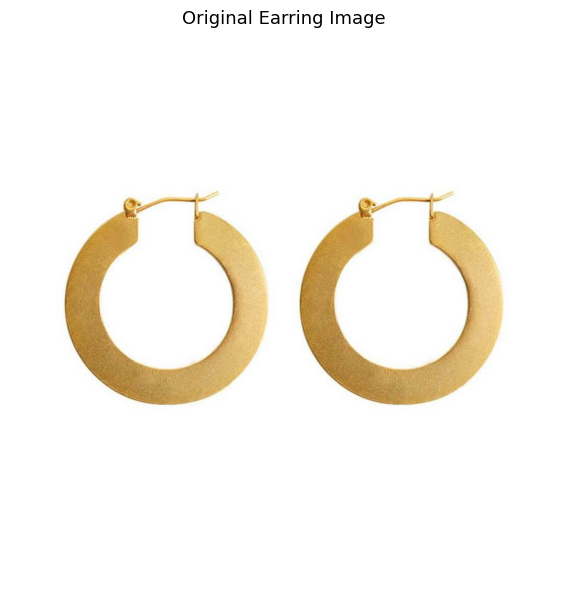

In [2]:
# Visualise the original earring image
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.imshow(img_rgb)
ax.set_title('Original Earring Image', fontsize=13)
ax.axis('off')

plt.tight_layout()
os.makedirs('../outputs/q2', exist_ok=True)
plt.savefig('../outputs/q2/q2_original.png', dpi=150, bbox_inches='tight')
plt.show()


## Camera Geometry — Thin Lens Equation

In [3]:
# ── Camera parameters ────────────────────────────────────────────────
f_mm = 8.0       # focal length (mm)
p_mm = 0.0022    # pixel size   (mm)  =  2.2 micrometres
u_mm = 720.0     # object distance: lens to earring plane (mm)

# ── Thin lens equation
v_mm = (f_mm * u_mm) / (u_mm - f_mm)

# Magnification m = v / u 
mag = v_mm / u_mm

print("=== Camera Geometry ===")
print(f"  Focal length         f  =  {f_mm} mm")
print(f"  Object distance      u  =  {u_mm} mm   (lens to earring plane)")
print(f"  Image distance       v  =  {v_mm:.4f} mm   (thin lens equation)")
print(f"  Magnification        m  =  v / u  =  {mag:.6f}")
print(f"  Pixel size           p  =  {p_mm} mm")
print()
print("Verification — 1/v + 1/u should equal 1/f:")
print(f"  1/v + 1/u  =  {1/v_mm + 1/u_mm:.6f}")
print(f"  1/f        =  {1/f_mm:.6f}")


=== Camera Geometry ===
  Focal length         f  =  8.0 mm
  Object distance      u  =  720.0 mm   (lens to earring plane)
  Image distance       v  =  8.0899 mm   (thin lens equation)
  Magnification        m  =  v / u  =  0.011236
  Pixel size           p  =  0.0022 mm

Verification — 1/v + 1/u should equal 1/f:
  1/v + 1/u  =  0.125000
  1/f        =  0.125000


## Measuring Earring Size in Pixels

In [4]:
# Detect earring boundaries using thresholding + contour detection

_, thresh_img = cv.threshold(img_gray, 200, 255, cv.THRESH_BINARY_INV)

contours, _ = cv.findContours(thresh_img, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Keep only large contours, the actual earrings, not noise.
earring_boxes = []
for c in contours:
    if cv.contourArea(c) > 10000:
        x, y, w_px, h_px = cv.boundingRect(c)
        earring_boxes.append((x, y, w_px, h_px))

print(f"Earrings detected: {len(earring_boxes)}")
print()
for idx, (x, y, w_px, h_px) in enumerate(earring_boxes):
    print(f"  Earring {idx+1}:  x={x}, y={y},  width={w_px} px,  height={h_px} px")


Earrings detected: 2

  Earring 1:  x=541, y=302,  width=358 px,  height=394 px
  Earring 2:  x=102, y=302,  width=365 px,  height=394 px


## Physical Size Calculation

In [5]:
# Physical size formula

print("=== Physical Size Results ===")
print()

sizes_mm = []
for idx, (x, y, w_px, h_px) in enumerate(earring_boxes):
    W_mm = (w_px * p_mm) / mag    # real width  in mm
    H_mm = (h_px * p_mm) / mag    # real height in mm
    sizes_mm.append((W_mm, H_mm))
    print(f"  Earring {idx+1}:")
    print(f"    Pixel size     :  {w_px} x {h_px} px")
    print(f"    Physical width :  ({w_px} × {p_mm}) / {mag:.6f}  =  {W_mm:.2f} mm")
    print(f"    Physical height:  ({h_px} × {p_mm}) / {mag:.6f}  =  {H_mm:.2f} mm")
    print(f"    Outer diameter :  ~{(W_mm + H_mm) / 2:.2f} mm")
    print()

avg_W = np.mean([s[0] for s in sizes_mm])
avg_H = np.mean([s[1] for s in sizes_mm])
print(f"  Average outer dimensions : {avg_W:.2f} x {avg_H:.2f} mm")
print(f"  Average outer diameter   : ~{(avg_W + avg_H) / 2:.2f} mm")


=== Physical Size Results ===

  Earring 1:
    Pixel size     :  358 x 394 px
    Physical width :  (358 × 0.0022) / 0.011236  =  70.10 mm
    Physical height:  (394 × 0.0022) / 0.011236  =  77.15 mm
    Outer diameter :  ~73.62 mm

  Earring 2:
    Pixel size     :  365 x 394 px
    Physical width :  (365 × 0.0022) / 0.011236  =  71.47 mm
    Physical height:  (394 × 0.0022) / 0.011236  =  77.15 mm
    Outer diameter :  ~74.31 mm

  Average outer dimensions : 70.78 x 77.15 mm
  Average outer diameter   : ~73.96 mm


## Visualisation — Annotated Measurements

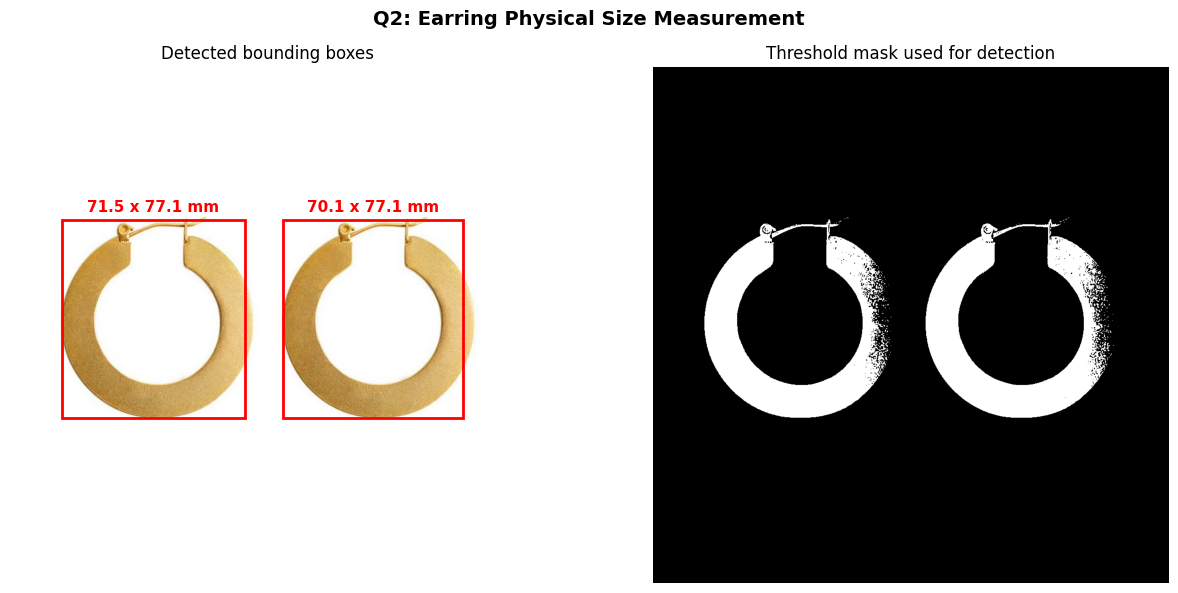

In [6]:
# Draw bounding boxes and size annotations on the image
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Q2: Earring Physical Size Measurement', fontsize=14, fontweight='bold')

# Left: annotated image
axes[0].imshow(img_rgb)
for idx, (x, y, w_px, h_px) in enumerate(earring_boxes):
    W_mm = (w_px * p_mm) / mag
    H_mm = (h_px * p_mm) / mag
    rect = patches.Rectangle((x, y), w_px, h_px,
                               linewidth=2, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(x + w_px // 2, y - 15,
                 f'{W_mm:.1f} x {H_mm:.1f} mm',
                 color='red', fontsize=11, fontweight='bold', ha='center')
axes[0].set_title('Detected bounding boxes', fontsize=12)
axes[0].axis('off')

# Right: thresholded image used for detection
axes[1].imshow(thresh_img, cmap='gray')
axes[1].set_title('Threshold mask used for detection', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q2/q2_earring_measurement.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Summary table
print(f"{'Parameter':<30} {'Value':>15}")
print("-" * 46)
print(f"{'Focal length  f':<30} {f_mm:>14.1f} mm")
print(f"{'Object distance  u':<30} {u_mm:>14.1f} mm")
print(f"{'Image distance  v':<30} {v_mm:>14.4f} mm")
print(f"{'Magnification  m':<30} {mag:>14.6f}")
print(f"{'Pixel size  p':<30} {p_mm:>14.4f} mm")
print("-" * 46)
for idx, (W_mm, H_mm) in enumerate(sizes_mm):
    print(f"{'Earring ' + str(idx+1) + '  width':<30} {W_mm:>14.2f} mm")
    print(f"{'Earring ' + str(idx+1) + '  height':<30} {H_mm:>14.2f} mm")
    print(f"{'Earring ' + str(idx+1) + '  outer diameter':<30} {(W_mm+H_mm)/2:>14.2f} mm")


Parameter                                Value
----------------------------------------------
Focal length  f                           8.0 mm
Object distance  u                      720.0 mm
Image distance  v                      8.0899 mm
Magnification  m                     0.011236
Pixel size  p                          0.0022 mm
----------------------------------------------
Earring 1  width                        70.10 mm
Earring 1  height                       77.15 mm
Earring 1  outer diameter               73.62 mm
Earring 2  width                        71.47 mm
Earring 2  height                       77.15 mm
Earring 2  outer diameter               74.31 mm
